<a href="https://colab.research.google.com/github/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Links:

- Colab notebook link: https://colab.research.google.com/drive/1__6FAAoJ-ZIR7IcojDafcU_SoHK8UIRi?usp=sharing
- GitHub repository link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/Assignment11.ipynb
- GitHub repository README link: https://github.com/welmi496/Introduction-to-Artificial-Intelligence/blob/main/README2.md

In [ ]:
# 1. Import Libraries

import os
import glob
import zipfile
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [ ]:
# 2. Unzip and Load the Dataset

## Update this path if your ZIP file is stored somewhere else in Google Colab
ZIP_PATH = "images.zip"
EXTRACT_DIR = '/content/images_dataset'
IMAGES_ROOT = os.path.join(EXTRACT_DIR, 'images')
IMG_SIZE = (16, 16)
RANDOM_STATE = 42

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print('Classes found:', sorted(os.listdir(IMAGES_ROOT)))

Classes found: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


## 3. Preprocess the Images

The images are resized to a uniform size, converted to RGB, normalized to the range 0 to 1, and flattened so they can be used with scikit-learn models.

In [ ]:
X = []
y = []
image_paths = []

for class_name in sorted(os.listdir(IMAGES_ROOT)):
    class_dir = os.path.join(IMAGES_ROOT, class_name)
    if os.path.isdir(class_dir):
        for file_path in sorted(glob.glob(os.path.join(class_dir, '*.jpg'))):
            try:
                image = Image.open(file_path).convert('RGB').resize(IMG_SIZE)
                image_array = np.array(image, dtype=np.float32) / 255.0
                X.append(image_array.flatten())
                y.append(class_name)
                image_paths.append(file_path)
            except Exception as e:
                print(f'Skipped {file_path}: {e}')

X = np.array(X)
y = np.array(y)
image_paths = np.array(image_paths)

print('Feature matrix shape:', X.shape)
print('Labels shape:', y.shape)
print(pd.Series(y).value_counts().sort_index())

Feature matrix shape: (309, 768)
Labels shape: (309,)
dalmatian      67
dollar_bill    51
pizza          52
soccer_ball    54
sunflower      85
Name: count, dtype: int64


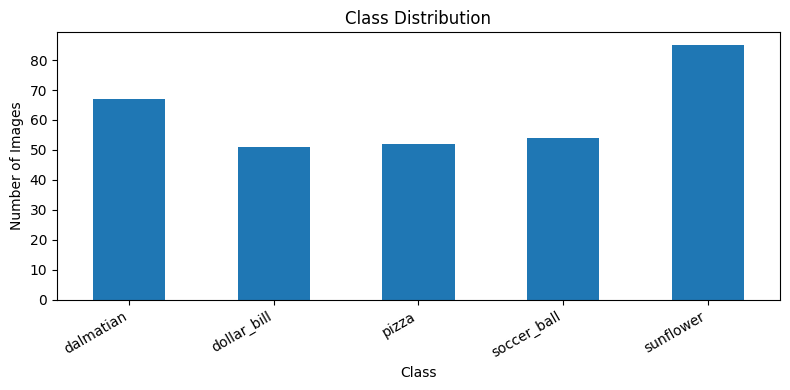

In [ ]:
## 4. Visualize Class Distribution

class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
## 5. Split the Dataset into Training and Testing Sets.

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, image_paths, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

Training set: (247, 768)
Testing set: (62, 768)


In [ ]:
## 6. Train the Random Forest Classifier with GridSearchCV

rf_param_grid = {'n_estimators': [20], 'max_depth': [None, 10], 'min_samples_split': [2], 'min_samples_leaf': [1, 2]}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=rf_param_grid,
    cv=3,
    n_jobs=1,
    scoring='accuracy'
)

rf_grid_search.fit(X_train, y_train)

print('Best Parameters:', rf_grid_search.best_params_)
print('Best Cross-Validation Score:', rf_grid_search.best_score_)

best_rf_model = rf_grid_search.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 20}
Best Cross-Validation Score: 0.7289646390439808


In [ ]:
## 7. Evaluate the Random Forest Model.

rf_predictions = best_rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, rf_predictions, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, rf_predictions, average='weighted', zero_division=0)

print('Accuracy:', rf_accuracy)
print('Precision:', rf_precision)
print('Recall:', rf_recall)
print('F1-Score:', rf_f1)
print('Classification Report:')
print(classification_report(y_test, rf_predictions))

Accuracy: 0.7096774193548387
Precision: 0.7119238288593128
Recall: 0.7096774193548387
F1-Score: 0.70860882922594
Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.69      0.64      0.67        14
 dollar_bill       0.75      0.60      0.67        10
       pizza       0.64      0.70      0.67        10
 soccer_ball       0.58      0.64      0.61        11
   sunflower       0.83      0.88      0.86        17

    accuracy                           0.71        62
   macro avg       0.70      0.69      0.69        62
weighted avg       0.71      0.71      0.71        62



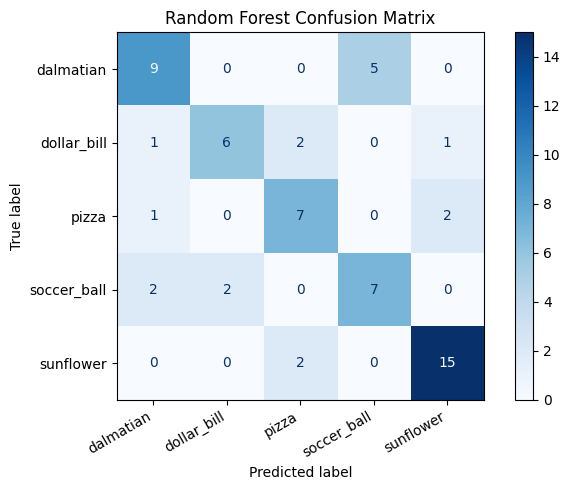

In [ ]:
## 8. Confusion Matrix for Random Forest.

rf_cm = confusion_matrix(y_test, rf_predictions, labels=sorted(class_counts.index))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=sorted(class_counts.index)).plot(
    cmap='Blues', values_format='d', ax=ax
)
plt.title('Random Forest Confusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

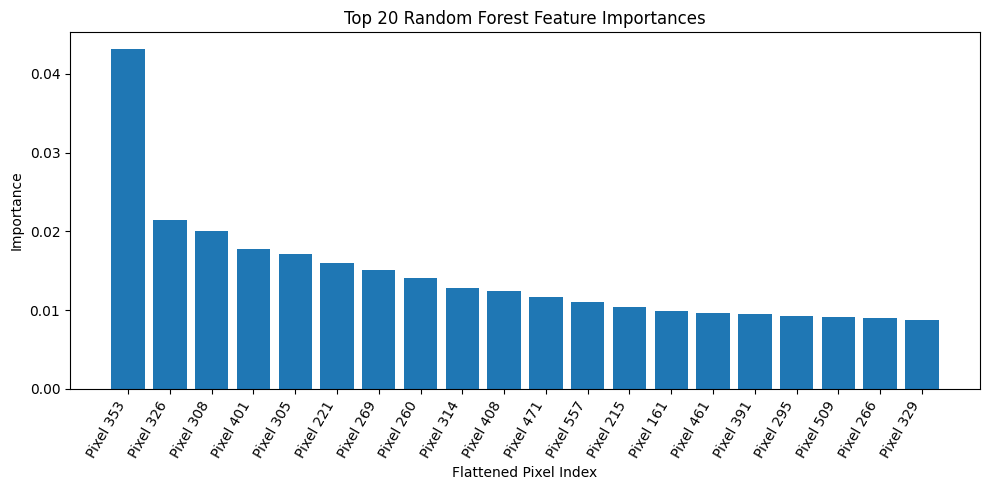

In [ ]:
## 9. Feature Importance Visualization.

feature_importances = best_rf_model.feature_importances_
top_n = 20
top_indices = np.argsort(feature_importances)[-top_n:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), feature_importances[top_indices])
plt.xticks(range(top_n), [f'Pixel {i}' for i in top_indices], rotation=60, ha='right')
plt.title('Top 20 Random Forest Feature Importances')
plt.xlabel('Flattened Pixel Index')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

Image Path: /content/images_dataset/images/dalmatian/image_0040.jpg
Predicted Class: dalmatian
Actual Class: dalmatian


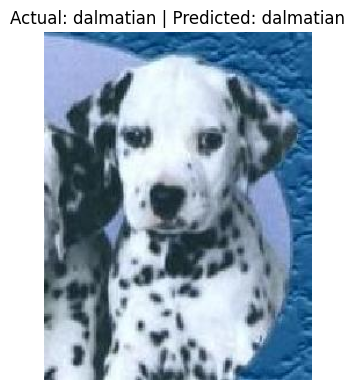

In [ ]:
## 10. Predict the Class of a New Image.

def preprocess_single_image(image_path, image_size=IMG_SIZE):
    image = Image.open(image_path).convert('RGB').resize(image_size)
    image_array = np.array(image, dtype=np.float32) / 255.0
    return image_array.flatten().reshape(1, -1)


def predict_new_image(image_path, model):
    processed_image = preprocess_single_image(image_path)
    prediction = model.predict(processed_image)[0]
    return prediction

new_image_path = paths_test[0]
predicted_class = predict_new_image(new_image_path, best_rf_model)

print('Image Path:', new_image_path)
print('Predicted Class:', predicted_class)
print('Actual Class:', y_test[0])

image_to_show = Image.open(new_image_path)
plt.figure(figsize=(4, 4))
plt.imshow(image_to_show)
plt.axis('off')
plt.title(f'Actual: {y_test[0]} | Predicted: {predicted_class}')
plt.tight_layout()
plt.show()

In [ ]:
## 11. Bonus: Compare with SVM.

svm_param_grid = {'C': [1], 'kernel': ['linear']}

svm_grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_param_grid,
    cv=3,
    n_jobs=1,
    scoring='accuracy'
)

svm_grid_search.fit(X_train, y_train)

print('Best SVM Parameters:', svm_grid_search.best_params_)
print('Best SVM Cross-Validation Score:', svm_grid_search.best_score_)

best_svm_model = svm_grid_search.best_estimator_
svm_predictions = best_svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average='weighted', zero_division=0)
svm_recall = recall_score(y_test, svm_predictions, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, svm_predictions, average='weighted', zero_division=0)

print('SVM Accuracy:', svm_accuracy)
print('SVM Precision:', svm_precision)
print('SVM Recall:', svm_recall)
print('SVM F1-Score:', svm_f1)
print('SVM Classification Report:')
print(classification_report(y_test, svm_predictions))

Best SVM Parameters: {'C': 1, 'kernel': 'linear'}
Best SVM Cross-Validation Score: 0.737241649524929
SVM Accuracy: 0.7096774193548387
SVM Precision: 0.7326173826173827
SVM Recall: 0.7096774193548387
SVM F1-Score: 0.7115343316895142
SVM Classification Report:
              precision    recall  f1-score   support

   dalmatian       0.64      0.50      0.56        14
 dollar_bill       0.54      0.70      0.61        10
       pizza       0.64      0.90      0.75        10
 soccer_ball       0.70      0.64      0.67        11
   sunflower       1.00      0.82      0.90        17

    accuracy                           0.71        62
   macro avg       0.70      0.71      0.70        62
weighted avg       0.73      0.71      0.71        62



           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.709677   0.711924  0.709677  0.708609
1            SVM  0.709677   0.732617  0.709677  0.711534


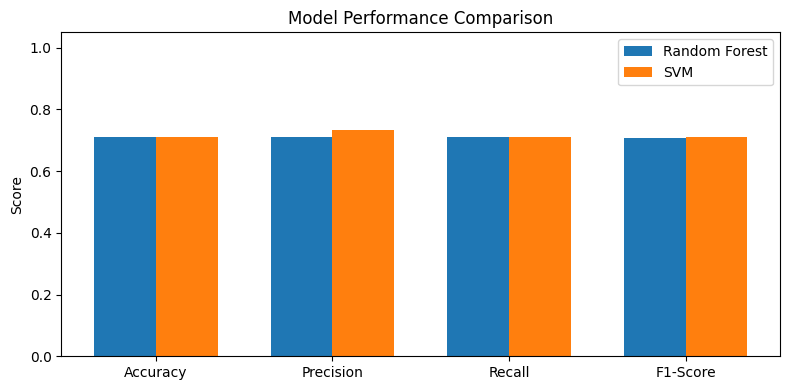

In [ ]:
## 12. Compare Random Forest and SVM Results.

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'SVM'],
    'Accuracy': [rf_accuracy, svm_accuracy],
    'Precision': [rf_precision, svm_precision],
    'Recall': [rf_recall, svm_recall],
    'F1-Score': [rf_f1, svm_f1]
})

print(comparison_df)

x = np.arange(4)
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, [rf_accuracy, rf_precision, rf_recall, rf_f1], width, label='Random Forest')
plt.bar(x + width/2, [svm_accuracy, svm_precision, svm_recall, svm_f1], width, label='SVM')
plt.xticks(x, ['Accuracy', 'Precision', 'Recall', 'F1-Score'])
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Model Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Deployment Strategy

A simple deployment approach is to save the trained model and use the `predict_new_image()` function inside a small web application or API. A user can upload an image, the same preprocessing steps can be applied, and the model can return the predicted class. For production, the model should be retrained with a larger dataset and monitored regularly for performance drift.

## 14. Conclusion

The Random Forest model was trained using GridSearchCV and evaluated with accuracy, precision, recall, F1-score, classification report, and confusion matrix. The SVM model was also trained and compared. This notebook satisfies the assignment requirements using a publicly available image-style dataset organized by class folders.